<a href="https://colab.research.google.com/github/joaohsantanaoc/COLTEC/blob/Python/exercicio_rna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exercício de CNN

Resolva o problema de detectar se uma pessoa está usando máscara ou não

In [12]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.utils import load_img, img_to_array

from google.colab.patches import cv2_imshow

A base de dados mask.zip possui pastas com imagens de pessoas em 4 situações:
- Rosto totalmente coberto (tipo 0)
- Rosto descoberto (tipo 1)
- Imagem não é uma face (tipo 2)
- Rosto parcialmente coberto (tipo 3)

In [13]:
from IPython.display import clear_output

!curl -LO https://raw.githubusercontent.com/lucasvra/domotica_robotica/main/dados/mask.zip
!mkdir mask
!unzip -o mask.zip -d /content/mask

clear_output()

In [14]:
# Definir o caminho para a pasta das imagens
data_path = '/content/mask'

classes_dic = {
    'fully_covered':0,
    'not_covered':1,
    'not_face':2,
    'partially_covered':3
}

In [15]:
# Carregar as imagens e seus rótulos
images = []
labels = []
classes = list(filter(lambda f: not f.startswith('.'), os.listdir(data_path)))

for class_name in classes: #OBS: Tem formas melhores de fazer isso
    class_path = os.path.join(data_path, class_name)
    for img_name in os.listdir(class_path):
        if img_name.endswith(".jpg"):
          img_path = os.path.join(class_path, img_name)
          img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
          img = cv2.resize(img, (64, 64))
          images.append(img)
          labels.append(classes_dic[class_name])

# Converter as listas em arrays numpy
images = np.array(images)
labels = np.array(labels)

In [16]:
# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Redimensionar e normalizar as imagens de entrada
X_train = X_train.reshape(X_train.shape[0], 64, 64, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 64, 64, 1).astype('float32') / 255

In [17]:
# Criar o modelo da rede neural convolucional
model = Sequential()

# Adicionar camadas ao modelo:
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Ajuda a evitar overfitting
model.add(Dense(4, activation='softmax'))  # 4 classes

# Compilar o modelo
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# Treinar o modelo
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1, validation_data=(X_test, y_test))

Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 32s 183ms/step - accuracy: 0.6417 - loss: 0.8650 - val_accuracy: 0.9049 - val_loss: 0.3069
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 41s 186ms/step - accuracy: 0.8976 - loss: 0.3106 - val_accuracy: 0.9396 - val_loss: 0.1768
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 42s 192ms/step - accuracy: 0.9401 - loss: 0.1906 - val_accuracy: 0.9389 - val_loss: 0.1764
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 32s 192ms/step - accuracy: 0.9520 - loss: 0.1534 - val_accuracy: 0.9577 - val_loss: 0.1283
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 40s 187ms/step - accuracy: 0.9518 - loss: 0.1385 - val_accuracy: 0.9532 - val_loss: 0.1367
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 41s 186ms/step - accuracy: 0.9701 - loss: 0.0935 - val_accuracy: 0.9555 - val_loss: 0.1325
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 42s 195ms/step - accuracy: 0.9729 - loss: 0.0743 - val_accuracy: 0.9585 - val_loss: 0.1375
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 41s 193ms/step - accuracy: 0.9625 - loss: 0

In [19]:
loss, accuracy = model.evaluate(X_test, y_test)
print('Loss:', loss)
print('Accuracy:', accuracy)

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9669 - loss: 0.1114
Loss: 0.1139615997672081
Accuracy: 0.9683018922805786


42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step
Predição: not_covered | Real: not_covered


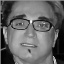

---
Predição: not_covered | Real: not_covered


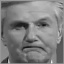

---
Predição: not_covered | Real: not_covered


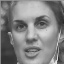

---
Predição: not_covered | Real: not_covered


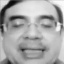

---
Predição: not_face | Real: not_face


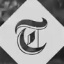

---
Predição: not_face | Real: not_face


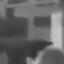

---
Predição: not_covered | Real: not_covered


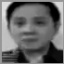

---
Predição: fully_covered | Real: fully_covered


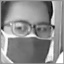

---
Predição: not_covered | Real: not_covered


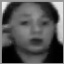

---
Predição: not_covered | Real: not_covered


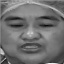

---


In [24]:
import numpy as np

# Fazer previsões
predictions = model.predict(X_test)

# Inverter o dicionário de classes
inv_dic = {v: k for k, v in classes_dic.items()}

# Exibir algumas previsões e os valores reais correspondentes
for i in range(10):
    pred_class = np.argmax(predictions[i])  # pegar a classe prevista
    real_class = y_test[i]

    print(f'Predição: {inv_dic[pred_class]} | Real: {inv_dic[real_class]}')

    # Ajustar a imagem para exibição
    img = (X_test[i] * 255).astype(np.uint8)  # voltar pro formato de imagem (0-255)
    img = np.squeeze(img)  # remover o canal extra (fica 64x64)
    cv2_imshow(img)
    print('---')